In [1]:
# Data Acquisition and Exploratory Data Analysis

## Objective
In this notebook, we will explore the UCI Heart Disease dataset and understand the data before building a prediction model. We will examine the features, check the data quality, and prepare it for later analysis. The original target values range from 0 to 4, and these will later be converted into a binary classification problem where 0 means no heart disease and 1 means heart disease.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

from IPython.display import display
plt.style.use('seaborn-v0_8')
warnings.filterwarnings('ignore', category=FutureWarning)


## Load Dataset

The dataset downloaded from the UCI repository is loaded into a pandas DataFrame. The following code displays the dataset shape and a few sample records to verify that the data has been loaded correctly.

In [3]:
# Load the dataset
heart_df = pd.read_csv("../data/raw/heart_disease.csv")

# Display basic information
print("=" * 60)
print("Dataset Successfully Loaded")
print("=" * 60)

print(f"\nDataset Shape: {heart_df.shape}")

print("\nFirst 5 Rows")
display(heart_df.head())

print("\nLast 5 Rows")
display(heart_df.tail())

print("\nRandom Sample (5 Rows)")
display(heart_df.sample(5, random_state=42))


Dataset Successfully Loaded

Dataset Shape: (303, 14)

First 5 Rows


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Last 5 Rows


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0



Random Sample (5 Rows)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
179,53.0,1.0,3.0,130.0,246.0,1.0,2.0,173.0,0.0,0.0,1.0,3.0,3.0,0
228,54.0,1.0,4.0,110.0,206.0,0.0,2.0,108.0,1.0,0.0,2.0,1.0,3.0,3
111,56.0,1.0,4.0,125.0,249.0,1.0,2.0,144.0,1.0,1.2,2.0,1.0,3.0,1
246,58.0,1.0,4.0,100.0,234.0,0.0,0.0,156.0,0.0,0.1,1.0,1.0,7.0,2
60,51.0,0.0,4.0,130.0,305.0,0.0,0.0,142.0,1.0,1.2,2.0,0.0,7.0,2


## Initial Data Inspection

This section helps us understand the dataset before any cleaning or modeling. We will check the structure, summary statistics, data types, duplicates, and missing values.

In [4]:

# Basic dataset inspection
print("1. Dataset Information")
heart_df.info()
print("\nObservation: This shows the number of rows, columns, and whether any values are missing.")

print("\n2. Summary Statistics")
display(heart_df.describe())
print("\nObservation: This gives a quick summary of the numerical columns, such as the average and range of values.")

print("\n3. Data Types")
display(heart_df.dtypes.to_frame("data_type"))
print("\nObservation: This tells us which columns are numbers and which ones are categories.")

print("\n4. Duplicate Rows")
duplicate_count = heart_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
print("\nObservation: If this number is greater than zero, some rows appear more than once.")

print("\n5. Missing Values")
missing_values = heart_df.isnull().sum()
display(missing_values.to_frame("missing_count"))
print("\nObservation: Missing values can affect model training, so we should note where they appear.")

1. Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Observation: This shows the number of rows, columns, and whether any values are missing.

2. Summary Statistics


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000



Observation: This gives a quick summary of the numerical columns, such as the average and range of values.

3. Data Types


,data_type
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64



Observation: This tells us which columns are numbers and which ones are categories.

4. Duplicate Rows
Number of duplicate rows: 0

Observation: If this number is greater than zero, some rows appear more than once.

5. Missing Values


,missing_count
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



Observation: Missing values can affect model training, so we should note where they appear.


## Target Variable Analysis

The target column in this dataset represents the severity of heart disease using the original UCI coding. This section examines the distribution of the original labels before any transformation is applied. In the later assignment workflow, these values will be converted into a binary classification target for model training.

- 0 = No Heart Disease
- 1 = Low Severity
- 2 = Medium Severity
- 3 = High Severity
- 4 = Very High Severity

Short observation: Understanding the distribution of the original target values is important because it helps us assess whether the classes are balanced or imbalanced before modeling.

Unique target values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Target value frequencies:


,frequency
target,
0,164
1,55
2,36
3,35
4,13


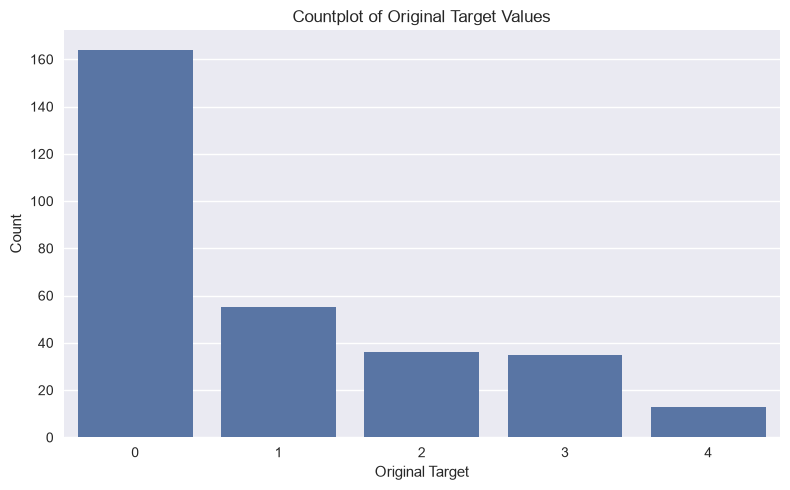

In [5]:
# Analyze the original target variable
target_column = "target"

print("Unique target values:", sorted(heart_df[target_column].unique()))

print("\nTarget value frequencies:")
display(heart_df[target_column].value_counts().sort_index().to_frame("frequency"))

plt.figure(figsize=(8, 5))
sns.countplot(data=heart_df, x=target_column, order=sorted(heart_df[target_column].unique()))
plt.title("Countplot of Original Target Values")
plt.xlabel("Original Target")
plt.ylabel("Count")
plt.xticks(ticks=range(5), labels=["0", "1", "2", "3", "4"])
plt.tight_layout()
plt.show()

### Observation
The original target distribution shows how many samples belong to each severity level before any binary conversion is applied.

Binary target value counts:


,frequency
target,
0,164
1,139


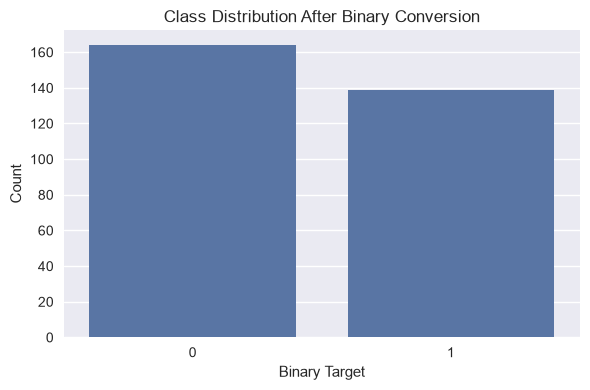


Unique labels after conversion: [np.int64(0), np.int64(1)]
✓ Target conversion verified successfully.


In [6]:
## Binary Target Conversion

#The original UCI target variable uses five severity levels. For this assignment, the problem is reframed as a binary classification task where the absence of disease is labeled as 0 and the presence of disease is labeled as 1. This conversion is a standard preprocessing step for classification models and preserves the core predictive objective while simplifying the label space.

# Create a copy for binary classification task
heart_df_binary = heart_df.copy()

# Convert the original target into binary labels
heart_df_binary["target"] = heart_df_binary["target"].apply(lambda x: 0 if x == 0 else 1)

print("Binary target value counts:")
display(heart_df_binary["target"].value_counts().sort_index().to_frame("frequency"))

plt.figure(figsize=(6, 4))
sns.countplot(data=heart_df_binary, x="target")
plt.title("Class Distribution After Binary Conversion")
plt.xlabel("Binary Target")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["0", "1"])
plt.tight_layout()
plt.show()

print("\nUnique labels after conversion:", sorted(heart_df_binary["target"].unique()))
assert set(heart_df_binary["target"].unique()) == {0, 1}

print("✓ Target conversion verified successfully.")


### Observation

- The transformed target now contains two classes only, which is appropriate for binary classification models such as logistic regression and random forest.

In [8]:
# Save the binary dataset for use in later notebooks and scripts
heart_df_binary.to_csv(
    "../data/processed/heart_disease_binary.csv",
    index=False
)

print("\nBinary dataset saved successfully.")


Binary dataset saved successfully.


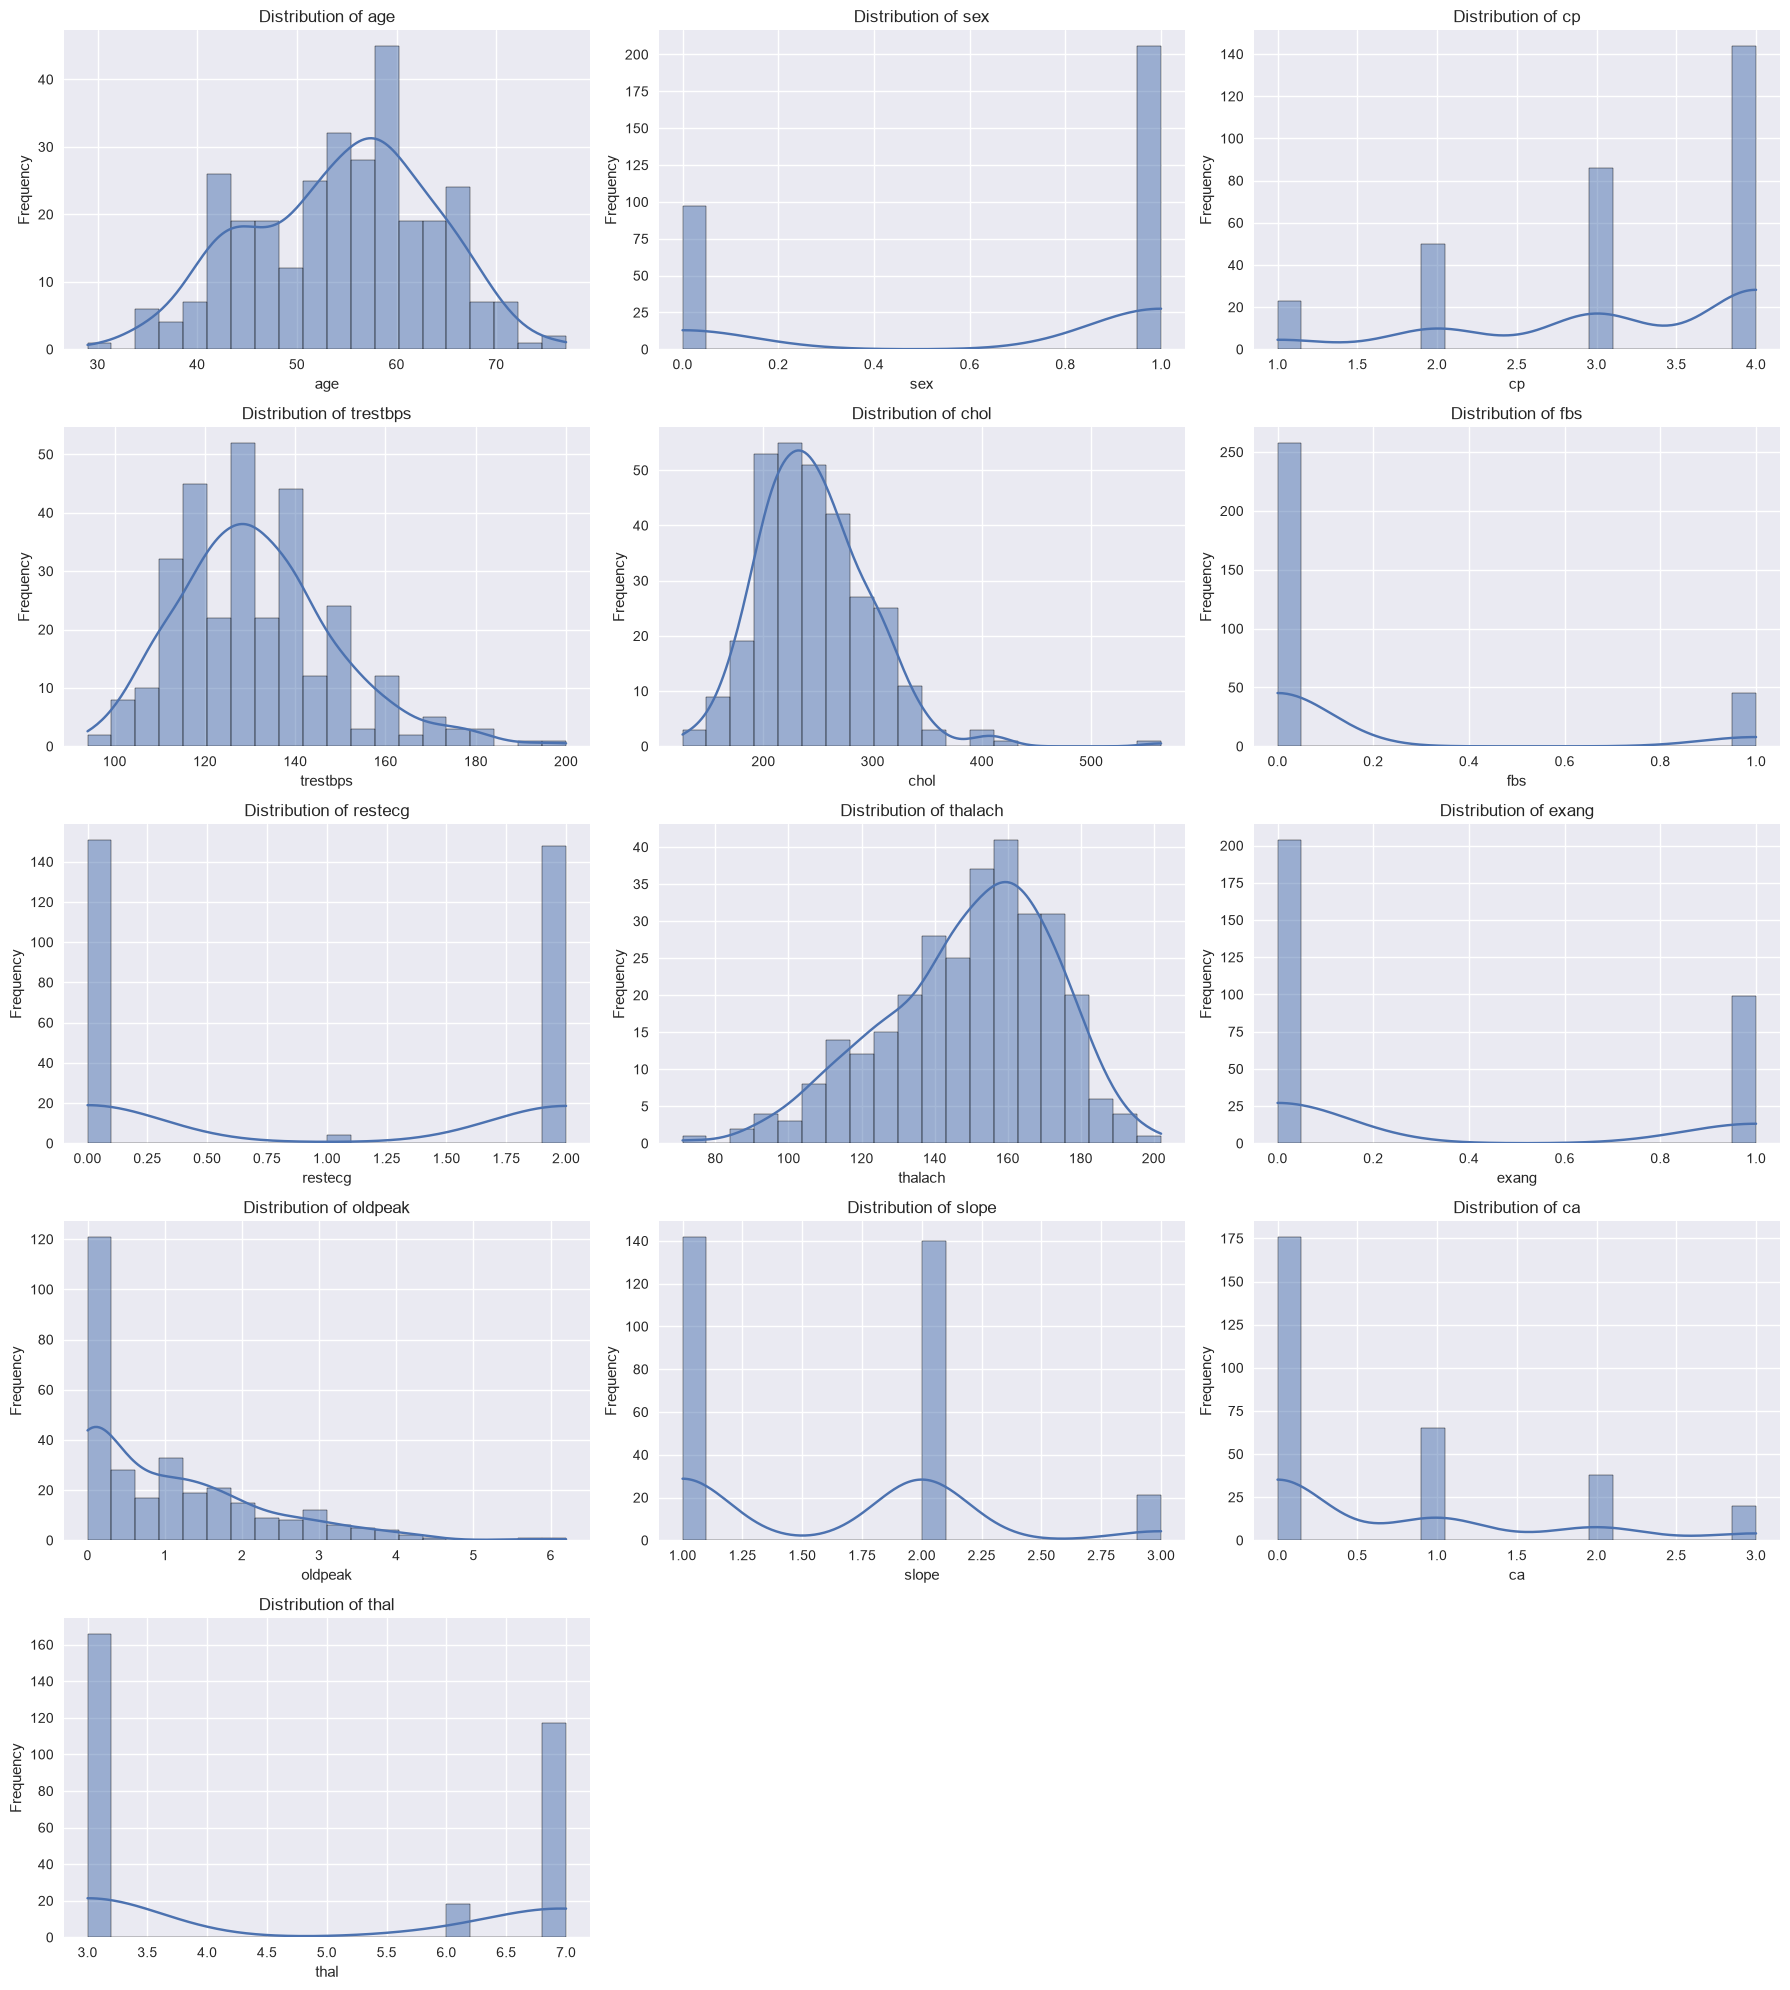

In [9]:
## Exploratory Data Analysis

#This section visualizes the numerical features of the dataset without performing any preprocessing or feature engineering. The goal is to inspect the distribution of each variable and identify any visible patterns or irregularities before modeling.

# Visualize the distribution of numerical features only
numeric_features = heart_df_binary.select_dtypes(include=[np.number]).columns.tolist()

# Exclude the target column from visualization because it is already transformed
numeric_features = [col for col in numeric_features if col != "target"]

num_cols = len(numeric_features)
rows = (num_cols + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(18, 4 * rows))
axes = axes.flatten()

for ax, feature in zip(axes, numeric_features):
    sns.histplot(heart_df_binary[feature], kde=True, bins=20, ax=ax)
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

for ax in axes[len(numeric_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


### Observation

- Most clinical features follow a non-uniform distribution.
- Cholesterol and resting blood pressure contain a few extreme values.
- Age is concentrated between approximately 40 and 65 years.
- These observations suggest that feature scaling and outlier analysis may be useful before model training.

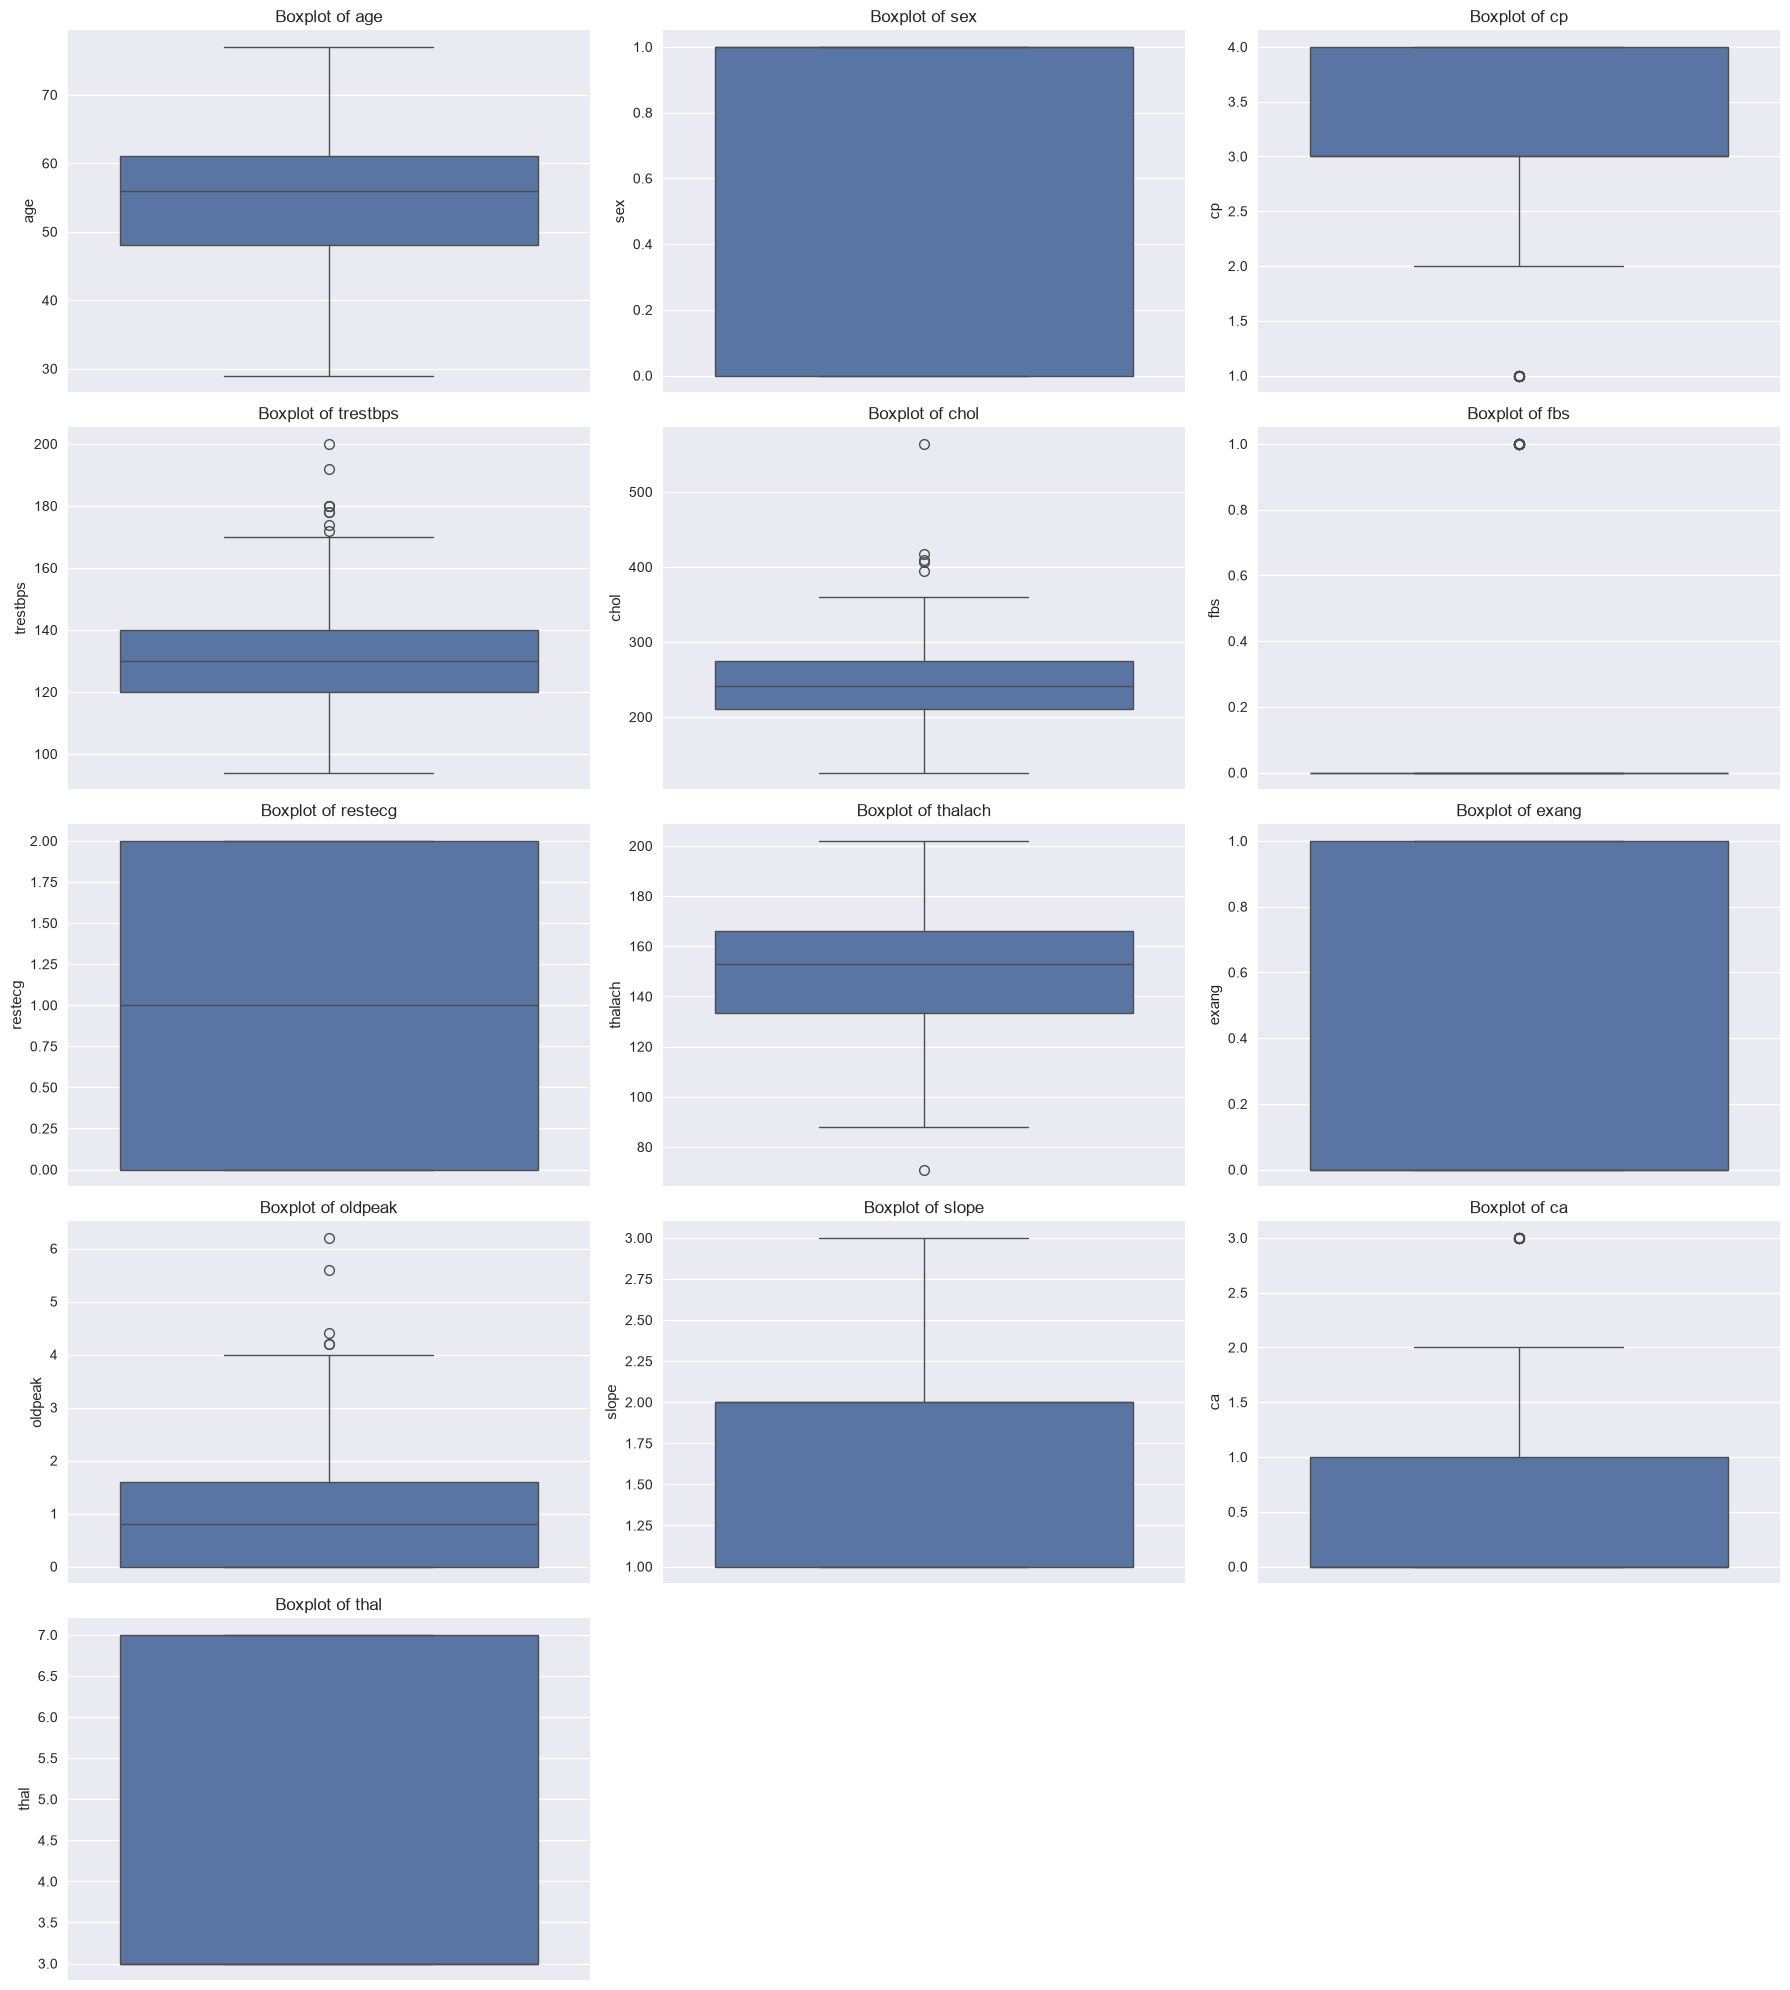

In [10]:
## Outlier Analysis using Boxplots

# This section visualizes the spread of each numerical feature using boxplots. The plots help identify unusual values and the overall distribution of the variables without removing any outliers.

# Plot boxplots for numerical features only
numeric_features = heart_df_binary.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_features if col != "target"]

num_cols = len(numeric_features)
rows = (num_cols + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(18, 4 * rows))
axes = axes.flatten()

for ax, feature in zip(axes, numeric_features):
    sns.boxplot(y=heart_df_binary[feature], ax=ax)
    ax.set_title(f"Boxplot of {feature}")
    ax.set_ylabel(feature)

for ax in axes[len(numeric_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Observation

- The boxplots show the spread and central tendency of each numerical feature.
- Several variables appear to contain extreme values, which may indicate outliers.
- These observations are useful for understanding the variability in the dataset before model training.


In [11]:
## Missing Value Analysis and Treatment

# The original UCI Heart Disease dataset contains missing entries represented by the symbol '?' in some columns. In pandas, these values are read as missing data, so this section identifies them and fills the numerical gaps using the median of each feature.

# Display missing values before treatment
print("Missing values before treatment:")
display(heart_df_binary.isnull().sum().to_frame("missing_count"))

print("\nExplanation: The original dataset used '?' for missing observations in some columns, so pandas reads them as NaN.")

# Replace missing values in numerical columns using the median
numeric_columns = heart_df_binary.select_dtypes(include=[np.number]).columns.tolist()
for column in numeric_columns:
    heart_df_binary[column] = heart_df_binary[column].fillna(heart_df_binary[column].median())

print("\nMissing values after treatment:")
display(heart_df_binary.isnull().sum().to_frame("missing_count"))

print("\nVerification: No missing values remain.")
assert heart_df_binary.isnull().sum().sum() == 0


Missing values before treatment:


,missing_count
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



Explanation: The original dataset used '?' for missing observations in some columns, so pandas reads them as NaN.

Missing values after treatment:


,missing_count
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



Verification: No missing values remain.


### Observation

- Missing values were present in the original dataset and were caused by '?' entries.
- Numerical columns were filled using the median, which is a simple and robust strategy for this assignment.
- The dataset is now ready for further modeling steps without missing values.


Pearson correlation matrix:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
age,1.000000,-0.097542,0.104139,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.365323,0.128303
sex,-0.097542,1.000000,0.010084,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.102173,0.037533,0.086048,0.380581
cp,0.104139,0.010084,1.000000,-0.036077,0.072319,-0.039975,0.067505,-0.334422,0.384060,0.202277,0.152050,0.233117,0.262089
trestbps,0.284946,-0.064456,-0.036077,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.097528,0.134424
chol,0.208950,-0.199915,0.072319,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.123726,0.018351
fbs,0.118530,0.047862,-0.039975,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.140764,0.064625
restecg,0.148868,0.021647,0.067505,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.131749,0.024325
thalach,-0.393806,-0.048663,-0.334422,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.265699,-0.274142
exang,0.091661,0.146201,0.384060,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.145788,0.325240
oldpeak,0.203805,0.102173,0.202277,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.301067,0.342405


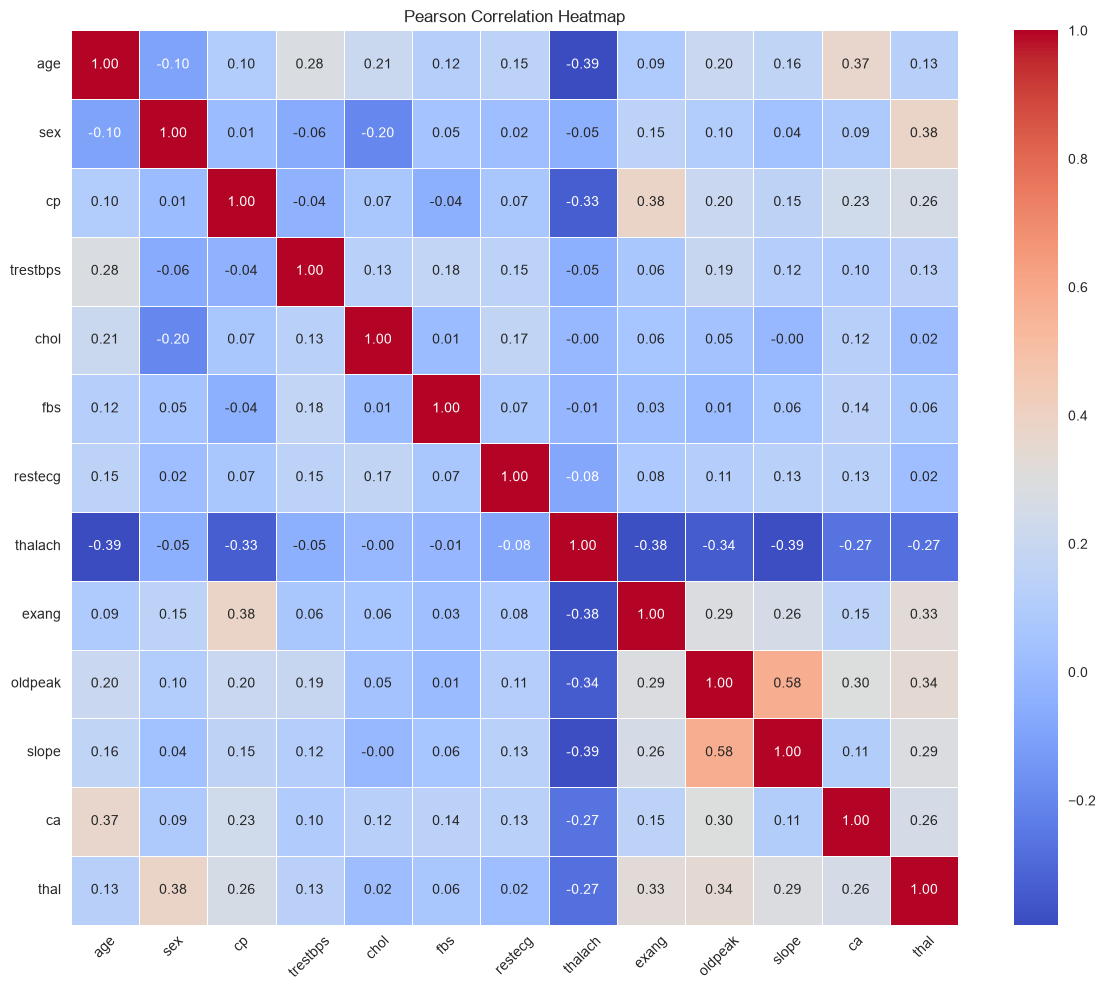

In [12]:
## Correlation Analysis

#This section examines the linear relationships between numerical features in the binary dataset. Pearson correlation is used to quantify the strength and direction of these relationships, which can help identify redundant or strongly associated predictors.

# Compute Pearson correlation for numerical features
numeric_features = heart_df_binary.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_features if col != "target"]

corr_matrix = heart_df_binary[numeric_features].corr(method="pearson")

print("Pearson correlation matrix:")
display(corr_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



### Observation

- Highly correlated features may provide similar information to a model and could be worth reviewing during later preprocessing.
- Strong positive or negative correlations can indicate meaningful relationships between clinical measurements.
- This analysis is useful for understanding feature redundancy before model development.

# Conclusion

The dataset has been successfully explored and converted into a binary classification problem.

Key observations:

- Dataset loaded successfully.
- Missing values identified.
- No duplicate records found.
- Target variable converted into binary classes.
- Initial feature distributions examined.

The processed dataset has been saved and will be used in the next notebook for preprocessing and model development.